# Introduction



## Problem Statement

Although extensive public data exist on poverty, educational attainment, unemployment, and population, these indicators are frequently stored in siloed systems and analyzed independently. This fragmentation limits the ability of public institutions—particularly those in rural regions—to conduct integrated, county-level assessments of regional need. As a result, many communities lack the analytic capacity to derive actionable insights that could inform local policy, educational programming, or economic development strategies.

The core data challenge is *twofold*:

1. Pattern Identification: Can we identify meaningful patterns and disparities in educational and economic conditions across counties in North Central Arkansas?

2. Predictive Insight: Can machine learning models be used to forecast future outcomes or classify counties based on shared vulnerabilities or developmental potential?

Addressing this challenge requires aggregating and standardizing multiple publicly available datasets, performing exploratory data analysis (EDA) to uncover relationships, and applying basic predictive modeling techniques to generate deeper insights. These insights can support more data-informed curriculum design, targeted workforce development programs, and competitive grant applications aligned with regional priorities.

## Section 1:  Work environment set up

In [73]:
# --- Standard Imports ---
import pandas as pd
import numpy as np
import warnings
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys



from pathlib import Path
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from collections import Counter

# --- Setup ---
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

# --- Paths ---
data_dir = Path("data")
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
figures_dir = output_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

log_dir = Path("logs")
log_dir.mkdir(exist_ok=True)

image_dir = Path("outputs/images")
image_dir.mkdir(parents=True, exist_ok=True)

# Clear existing handlers
logging.getLogger().handlers.clear()

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_dir / "project.log", mode='w', encoding='utf-8'),
        logging.StreamHandler(sys.stdout)
    ]
)

# --- Global Color Mapping for Key Variables (Percentages) ---
variable_colors = {
    "BachelorsDegreePct": "#1f77b4",   # Blue
    "HighSchoolGradPct": "#2ca02c",    # Green
    "PovertyRate": "#ff7f0e",          # Orange
    "UnemploymentRate": "#d62728"      # Red
}

print("Environment ready. Paths and logging configured.")



Environment ready. Paths and logging configured.


# Section 2: Load and prepare Data sets

## Section 2.1: Load utility functions and national datasets ----

In [74]:
# Section 2A: Load utility functions and national datasets ----

# Import custom utility functions
from utils import (
    standardize_column_names,
    extract_key_indicators,
    filter_to_county_level,
    log_duplicate_attributes,
    clean_and_extract_year,
    nca_counties
)

data_dir = Path("data")
complete_dir = data_dir / "complete_sets"

complete_files = {
    "edu": "Education2023.csv",
    "pop": "PopulationEstimates.csv",
    "poverty": "Poverty2023.csv",
    "unemp": "Unemployment2023.csv"
}


# Load, clean, and extract year from each dataset
complete_data = {}

for key, filename in complete_files.items():
    path = complete_dir / filename
    try:
        df = pd.read_csv(path, encoding='cp1252')
        df = standardize_column_names(df)
        logging.info(f" {key} columns after cleaning: {df.columns.tolist()}")
        df = filter_to_county_level(df)
        df = clean_and_extract_year(df)

        # Rename fields if necessary
        df.rename(columns={'area_name': 'county'}, inplace=True)

        log_duplicate_attributes(df, key)
        complete_data[key] = df
        logging.info(f"Loaded {filename}: {df.shape[0]} rows")

    except Exception as e:
        logging.error(f" Failed to load {filename}: {e}")


# Confirmation message
logging.info("Utility functions from utils.py loaded successfully.")


2025-07-10 10:51:32,834 [INFO]  edu columns after cleaning: ['ïfips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-10 10:51:33,257 [WARNING] edu has duplicate county-attribute pairs.
2025-07-10 10:51:33,258 [INFO] Loaded Education2023.csv: 169245 rows
2025-07-10 10:51:33,333 [INFO]  pop columns after cleaning: ['fipstxt', 'state', 'area_name', 'attribute', 'value']
2025-07-10 10:51:33,802 [WARNING] pop has duplicate county-attribute pairs.
2025-07-10 10:51:33,803 [INFO] Loaded PopulationEstimates.csv: 205108 rows
2025-07-10 10:51:33,844 [INFO]  poverty columns after cleaning: ['ïfips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-10 10:51:33,976 [WARNING] poverty has duplicate county-attribute pairs.
2025-07-10 10:51:33,977 [INFO] Loaded Poverty2023.csv: 79961 rows
2025-07-10 10:51:34,117 [INFO]  unemp columns after cleaning: ['fips_code', 'state', 'area_name', 'attribute', 'value']
2025-07-10 10:51:34,815 [INFO] Loaded Unemployment2023.csv: 324636 rows
2025-07-

## Section 2.2: Load and process national datasets

In [75]:
# Section 2.2: Load and process national datasets

complete_dir = data_dir / "complete_sets"
complete_files = {
    "edu": "Education2023.csv",
    "pop": "PopulationEstimates.csv",
    "poverty": "Poverty2023.csv",
    "unemp": "Unemployment2023.csv"
}

state_lookup = None

# Choose your analysis year here
selected_year = '2023'

for key, filename in complete_files.items():
    path = complete_dir / filename
    try:
        # Load and standardize
        df = pd.read_csv(path, encoding='cp1252')
        df = standardize_column_names(df)
        df = filter_to_county_level(df)
        df.rename(columns={'area_name': 'county', 'fips_code': 'fips', 'fipstxt': 'fips'}, inplace=True)
        df['county'] = df['county'].str.strip().str.lower()

        # Extract year from attribute
        if 'attribute' in df.columns:
            df = clean_and_extract_year(df)

            # Only filter datasets where year tagging applies
            if key in ['pop', 'poverty', 'unemp']:
                df = df[df['attribute_year'] == selected_year]

        # Save state info once from education
        if key == 'edu':
            state_lookup = df[['county', 'state']].drop_duplicates().copy()
            state_lookup['county'] = state_lookup['county'].str.lower().str.strip()
            state_lookup['state'] = state_lookup['state'].str.upper().str.strip()

        log_duplicate_attributes(df, key)
        complete_data[key] = df
        logging.info(f" Loaded and processed {filename} with year filter: {selected_year if key != 'edu' else 'N/A'}")

    except Exception as e:
        logging.error(f" Failed to load {filename}: {e}")


2025-07-10 10:51:35,426 [WARNING] edu has duplicate county-attribute pairs.
2025-07-10 10:51:35,431 [INFO]  Loaded and processed Education2023.csv with year filter: N/A
2025-07-10 10:51:35,971 [WARNING] pop has duplicate county-attribute pairs.
2025-07-10 10:51:35,975 [INFO]  Loaded and processed PopulationEstimates.csv with year filter: 2023
2025-07-10 10:51:36,161 [WARNING] poverty has duplicate county-attribute pairs.
2025-07-10 10:51:36,163 [INFO]  Loaded and processed Poverty2023.csv with year filter: 2023
2025-07-10 10:51:37,111 [INFO]  Loaded and processed Unemployment2023.csv with year filter: 2023


### Section 2.3: Discover Common Year Across Datasets

In [76]:
# Section 2.3: Discover Common Year Across Datasets

def get_attribute_year_counts(df):
    """Counts how often each extracted attribute_year appears."""
    if 'attribute' in df.columns:
        df = clean_and_extract_year(df)
        return Counter(df['attribute_year'].dropna().astype(str))
    return {}

year_summary = {}

# Loop through each dataset and extract year counts
for key, df in complete_data.items():
    year_counts = get_attribute_year_counts(df)
    year_summary[key] = year_counts

# Display results
print("Year coverage by dataset:")
all_years = set()

for key, counts in year_summary.items():
    print(f"\n {key.upper()}:")
    if counts:
        for year, count in sorted(counts.items()):
            print(f"  {year}: {count}")
            all_years.add(year)
    else:
        print("  No attribute_year values found.")

# Find common years across all datasets that have year values
datasets_with_years = [set(c.keys()) for c in year_summary.values() if c]
common_years = set.intersection(*datasets_with_years) if datasets_with_years else set()



print("\n Common years across all datasets with usable attribute_year:", sorted(common_years))


Year coverage by dataset:

 EDU:
  1970: 25488
  1980: 26136
  1990: 26167
  2000: 26176
  2012: 26192
  2013: 6442
  2023: 29422
  2024: 3222

 POP:
  2023: 53619

 POVERTY:
  2023: 19223

 UNEMP:
  2023: 19326

 Common years across all datasets with usable attribute_year: ['2023']


## Section 2.4: Subset Arkansas and NCA Counties (No Full Merge)

In [77]:
# Section 2.4: Subset Arkansas and NCA Counties (No Full Merge)

# Define NCA counties (lowercase, cleaned)
nca_cleaned = [c.lower().strip() for c in nca_counties]

# Function to filter, clean, and subset each dataset
def get_nca_subset(df, dataset_name):
    df = df.copy()
    df = df[df['state'].str.upper() == 'AR']
    df['county'] = (
        df['county']
        .str.replace(" county", "", regex=False)
        .str.replace(", ar", "", regex=False)
        .str.strip()
        .str.lower()
    )
    df_nca = df[df['county'].isin(nca_cleaned)].copy()
    logging.info(f"{dataset_name.upper()} → NCA rows: {df_nca.shape[0]}")
    return df_nca

# Get cleaned NCA subsets
edu_nca = get_nca_subset(complete_data['edu'], 'edu')
poverty_nca = get_nca_subset(complete_data['poverty'], 'poverty')
unemp_nca = get_nca_subset(complete_data['unemp'], 'unemp')
pop_nca = get_nca_subset(complete_data['pop'], 'pop')

# Pivot each to wide format
edu_wide = edu_nca.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
poverty_wide = poverty_nca.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
unemp_wide = unemp_nca.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')
pop_wide = pop_nca.pivot_table(index='county', columns='attribute', values='value', aggfunc='first')

# Merge NCA-wide datasets
df_nca = reduce(
    lambda left, right: pd.merge(left, right, on='county', how='outer'),
    [edu_wide, poverty_wide, unemp_wide, pop_wide]
)
# Flatten MultiIndex columns (from pivot operations)
df_nca.columns = [col if isinstance(col, str) else col[1] for col in df_nca.columns]

# Save and log
df_nca.to_csv(output_dir / f"nca_dataset_cleaned_{selected_year}.csv")
logging.info(f"NCA final dataset saved: nca_dataset_cleaned_{selected_year}.csv")
print(f"NCA dataset ready with shape: {df_nca.shape}")

2025-07-10 10:51:37,770 [INFO] EDU → NCA rows: 676
2025-07-10 10:51:37,776 [INFO] POVERTY → NCA rows: 78
2025-07-10 10:51:37,781 [INFO] UNEMP → NCA rows: 78
2025-07-10 10:51:37,797 [INFO] POP → NCA rows: 221
2025-07-10 10:51:37,809 [INFO] NCA final dataset saved: nca_dataset_cleaned_2023.csv
NCA dataset ready with shape: (13, 81)


## Section 2.5 Streamline NCA data set 

In [78]:
# Section 2.5 Streamline NCA data set 

print("Columns BEFORE renaming:")
print(df_nca.columns.tolist())

# Ensure 'county' is a column, not just an index
df_nca = df_nca.reset_index()

# Rename long education column labels for clarity
df_nca = df_nca.rename(columns={
    "percent of adults who are high school graduates (or equivalent), 2019-23": "HighSchoolGradRate",
    "percent of adults with a bachelor's degree or higher, 2019-23": "BachelorsDegreeRate",
    "pctpovall_2023": "PovertyRate",
    "unemployment_rate_2023": "UnemploymentRate",
    "pop_estimate_2023": "Population"
})


# If the education rates are actually raw counts (verify first!)
df_nca['BachelorsDegreePct'] = (df_nca['BachelorsDegreeRate'] / df_nca['Population']) * 100
df_nca['HighSchoolGradPct'] = (df_nca['HighSchoolGradRate'] / df_nca['Population']) * 100


summary_vars = [
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate',
    'Population'
]

# Select only the summary variables and 'county'
summary_vars = [var for var in summary_vars if var in df_nca.columns]

# Log final columns
logging.info(f"Final NCA columns: {df_nca.columns.tolist()}")

df_nca_final = df_nca[summary_vars + ['county']].set_index('county')

df_nca_final.to_csv(output_dir / "nca_final.csv", index=True)
logging.info("✅ Final analysis dataset saved as: nca_final.csv")



Columns BEFORE renaming:
['2013 rural-urban continuum code', '2013 urban influence code', '2023 rural-urban continuum code', '2024 urban influence code', "bachelor's degree or higher, 1990", "bachelor's degree or higher, 2000", "bachelor's degree or higher, 2008-12", "bachelor's degree or higher, 2019-23", 'four years of college or higher, 1970', 'four years of college or higher, 1980', 'high school diploma only, 1970', 'high school diploma only, 1980', 'high school graduate (or equivalency), 1990', 'high school graduate (or equivalency), 2000', 'high school graduate (or equivalency), 2008-12', 'high school graduate (or equivalency), 2019-23', 'less than a high school diploma, 1970', 'less than a high school diploma, 1980', 'less than high school graduate, 1990', 'less than high school graduate, 2000', 'less than high school graduate, 2008-12', 'less than high school graduate, 2019-23', 'percent of adults completing four years of college or higher, 1970', 'percent of adults completing 

# Section 3 Exploratory Data Overview (Tables & Summary Insights)

## Section 3.1 Dataset Overview

In [79]:
# Section 3.1: Dataset Overview
print("Dataset Dimensions (rows, columns):", df_nca_final.shape)

print("\n Column Names:")
for col in df_nca_final.columns:
    print(" -", col)

print("\n Dataset Info:")
df_nca_final.info()

print("\n Preview of First 5 Rows:")
display(df_nca_final.head())

Dataset Dimensions (rows, columns): (13, 5)

 Column Names:
 - BachelorsDegreePct
 - HighSchoolGradPct
 - PovertyRate
 - UnemploymentRate
 - Population

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, baxter to woodruff
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   BachelorsDegreePct  13 non-null     float64
 1   HighSchoolGradPct   13 non-null     float64
 2   PovertyRate         13 non-null     float64
 3   UnemploymentRate    13 non-null     float64
 4   Population          13 non-null     float64
dtypes: float64(5)
memory usage: 624.0+ bytes

 Preview of First 5 Rows:


,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate,Population
county,,,,,
baxter,0.043729,0.080813,16.0,3.6,42875.0
cleburne,0.071801,0.155012,13.5,3.9,25445.0
fulton,0.126570,0.328741,17.5,3.8,12421.0
independence,0.044027,0.102839,13.5,3.4,38320.0
izard,0.132050,0.251546,20.3,5.1,14169.0


## Section 3.2 Data Dictionary 

In [80]:
# Section 3.2: Data Dictionary Summary (for df_nca_final)

# Manually define the variable descriptions (aligned with df_nca_final)
data_dictionary = {
    "BachelorsDegreePct": "Percent of population with a bachelor’s degree (calculated from rate and population)",
    "HighSchoolGradPct": "Percent of population with a high school diploma or equivalent (calculated)",
    "PovertyRate": "Estimated percentage of residents living below the poverty line (2023)",
    "UnemploymentRate": "Estimated unemployment rate of labor force (2023)",
    "Population": "Estimated total population of the county (2023)"
}

# Convert to a DataFrame for display and export
dictionary_df = pd.DataFrame.from_dict(data_dictionary, orient='index', columns=['Description'])
dictionary_df.index.name = 'Variable'

# Display and save
display(dictionary_df)

dictionary_df.to_csv(output_dir / "nca_data_dictionary.csv")
logging.info("📖 Data dictionary saved to: nca_data_dictionary.csv")


,Description
Variable,
BachelorsDegreePct,Percent of population with a bachelor’s degree...
HighSchoolGradPct,Percent of population with a high school diplo...
PovertyRate,Estimated percentage of residents living below...
UnemploymentRate,Estimated unemployment rate of labor force (2023)
Population,Estimated total population of the county (2023)


2025-07-10 10:51:37,870 [INFO] 📖 Data dictionary saved to: nca_data_dictionary.csv


## Section 3.3 Descriptive Statistics

In [81]:
# Section 3.3: Per-Variable County-Level Tables

percent_vars = [
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate'
]

for var in percent_vars:
    var_table = df_nca_final[[var]].copy()
    var_table.columns = ['Value']
    var_table.index.name = 'County'

     # Round values
    var_table = var_table.round(3)

    # Display
    print(f"\n📊 {var} by County:")
    display(var_table)

        # Save to CSV
    filename = f"section3_2_{var.lower()}_by_county.csv"
    var_table.to_csv(output_dir / filename)
    logging.info(f"[Section 3.2] Saved: {filename}")



📊 BachelorsDegreePct by County:


,Value
County,
baxter,0.044
cleburne,0.072
fulton,0.127
independence,0.044
izard,0.132
jackson,0.079
marion,0.088
searcy,0.175
sharp,0.066


2025-07-10 10:51:37,891 [INFO] [Section 3.2] Saved: section3_2_bachelorsdegreepct_by_county.csv

📊 HighSchoolGradPct by County:


,Value
County,
baxter,0.081
cleburne,0.155
fulton,0.329
independence,0.103
izard,0.252
jackson,0.256
marion,0.206
searcy,0.467
sharp,0.226


2025-07-10 10:51:37,897 [INFO] [Section 3.2] Saved: section3_2_highschoolgradpct_by_county.csv

📊 PovertyRate by County:


,Value
County,
baxter,16.0
cleburne,13.5
fulton,17.5
independence,13.5
izard,20.3
jackson,24.6
marion,17.4
searcy,20.2
sharp,19.7


2025-07-10 10:51:37,903 [INFO] [Section 3.2] Saved: section3_2_povertyrate_by_county.csv

📊 UnemploymentRate by County:


,Value
County,
baxter,3.6
cleburne,3.9
fulton,3.8
independence,3.4
izard,5.1
jackson,5.1
marion,4.1
searcy,4.3
sharp,3.9


2025-07-10 10:51:37,909 [INFO] [Section 3.2] Saved: section3_2_unemploymentrate_by_county.csv


In [82]:
# Auto-Summary Per Variable

for var in percent_vars:
    series = df_nca_final[var]
    max_val = series.max()
    min_val = series.min()
    mean_val = series.mean()
    std_val = series.std()

    max_county = series.idxmax()
    min_county = series.idxmin()

    print(f"\n🧠 Insight Summary for {var}:")
    print(f"  - Average across counties: {mean_val:.3f}")
    print(f"  - Standard deviation: {std_val:.3f}")
    print(f"  - Highest: {max_val:.3f} ({max_county.title()})")
    print(f"  - Lowest: {min_val:.3f} ({min_county.title()})")



🧠 Insight Summary for BachelorsDegreePct:
  - Average across counties: 0.103
  - Standard deviation: 0.064
  - Highest: 0.266 (Woodruff)
  - Lowest: 0.025 (White)

🧠 Insight Summary for HighSchoolGradPct:
  - Average across counties: 0.267
  - Standard deviation: 0.189
  - Highest: 0.774 (Woodruff)
  - Lowest: 0.052 (White)

🧠 Insight Summary for PovertyRate:
  - Average across counties: 18.231
  - Standard deviation: 3.531
  - Highest: 24.600 (Jackson)
  - Lowest: 13.500 (Cleburne)

🧠 Insight Summary for UnemploymentRate:
  - Average across counties: 4.031
  - Standard deviation: 0.541
  - Highest: 5.100 (Izard)
  - Lowest: 3.400 (Independence)


## Section 3.4 Outlier/Range Table

In [83]:
# Section 3.5: Outlier / Range Table

print(" Outlier and Range Summary for Selected Indicators:\n")


for var in summary_vars:
    print(f" Top 3 counties by {var}:")
    display(df_nca_final[[var]].sort_values(by=var, ascending=False).head(3))
    
    print(f" Bottom 3 counties by {var}:")
    display(df_nca_final[[var]].sort_values(by=var, ascending=True).head(3))
    
    print("-" * 60)


 Outlier and Range Summary for Selected Indicators:

 Top 3 counties by BachelorsDegreePct:


,BachelorsDegreePct
county,
woodruff,0.266446
searcy,0.175360
izard,0.132050


 Bottom 3 counties by BachelorsDegreePct:


,BachelorsDegreePct
county,
white,0.025242
baxter,0.043729
independence,0.044027


------------------------------------------------------------
 Top 3 counties by HighSchoolGradPct:


...

------------------------------------------------------------
 Top 3 counties by Population:


,Population
county,
white,78452.0
baxter,42875.0
independence,38320.0


 Bottom 3 counties by Population:


,Population
county,
woodruff,5964.0
searcy,7806.0
fulton,12421.0


------------------------------------------------------------


## Section 3.5 County Summary Table

In [84]:
# Section 3.4: One CSV per County Profile

export_vars = percent_vars + ['Population']

for county, row in df_nca_final[export_vars].iterrows():
    county_df = row.to_frame(name='Value')
    county_df.index.name = 'Variable'
    
    filename = f"section3_4_{county.lower().replace(' ', '_')}_profile.csv"
    county_df.to_csv(output_dir / filename)
    logging.info(f"Saved profile: {filename}")


2025-07-10 10:51:37,986 [INFO] Saved profile: section3_4_baxter_profile.csv
2025-07-10 10:51:38,008 [INFO] Saved profile: section3_4_cleburne_profile.csv
2025-07-10 10:51:38,011 [INFO] Saved profile: section3_4_fulton_profile.csv
2025-07-10 10:51:38,012 [INFO] Saved profile: section3_4_independence_profile.csv
2025-07-10 10:51:38,018 [INFO] Saved profile: section3_4_izard_profile.csv
2025-07-10 10:51:38,019 [INFO] Saved profile: section3_4_jackson_profile.csv
2025-07-10 10:51:38,021 [INFO] Saved profile: section3_4_marion_profile.csv
2025-07-10 10:51:38,022 [INFO] Saved profile: section3_4_searcy_profile.csv
2025-07-10 10:51:38,029 [INFO] Saved profile: section3_4_sharp_profile.csv
2025-07-10 10:51:38,034 [INFO] Saved profile: section3_4_stone_profile.csv
2025-07-10 10:51:38,036 [INFO] Saved profile: section3_4_van_buren_profile.csv
2025-07-10 10:51:38,037 [INFO] Saved profile: section3_4_white_profile.csv
2025-07-10 10:51:38,038 [INFO] Saved profile: section3_4_woodruff_profile.csv


# Section 4 Data Visualizations & Pattern Discovery

## Section 4.1: Variable Review

In [85]:
# Section 4.1: Extract and Name Key Indicator Variables

# Define key indicators to plot
variables = [
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate',
    'Population'
]

print("Variables selected for visualization:")
for var in variables:
    print(f" - {var}")

print("\n Preview of data to visualize:")
display(df_nca_final[variables].head())

# Optional: Save preview for report
df_nca_final[variables].head().to_csv(figures_dir / "section4_2_preview_visualization_data.csv")
logging.info("Saved visualization data preview for Section 4.2.")


Variables selected for visualization:
 - BachelorsDegreePct
 - HighSchoolGradPct
 - PovertyRate
 - UnemploymentRate
 - Population

 Preview of data to visualize:


,BachelorsDegreePct,HighSchoolGradPct,PovertyRate,UnemploymentRate,Population
county,,,,,
baxter,0.043729,0.080813,16.0,3.6,42875.0
cleburne,0.071801,0.155012,13.5,3.9,25445.0
fulton,0.126570,0.328741,17.5,3.8,12421.0
independence,0.044027,0.102839,13.5,3.4,38320.0
izard,0.132050,0.251546,20.3,5.1,14169.0


2025-07-10 10:51:38,055 [INFO] Saved visualization data preview for Section 4.2.


## Section 4.2 Distribution Plots

2025-07-10 10:51:38,288 [INFO] 📊 Saved: section4_2_1_distribution_bachelorsdegreepct.png


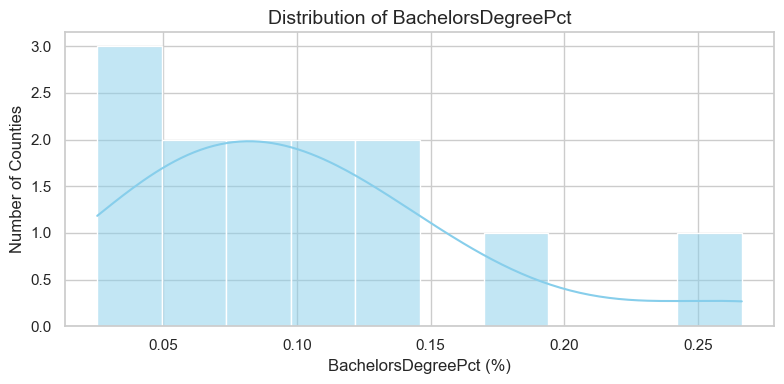

2025-07-10 10:51:38,529 [INFO] 📊 Saved: section4_2_1_distribution_highschoolgradpct.png


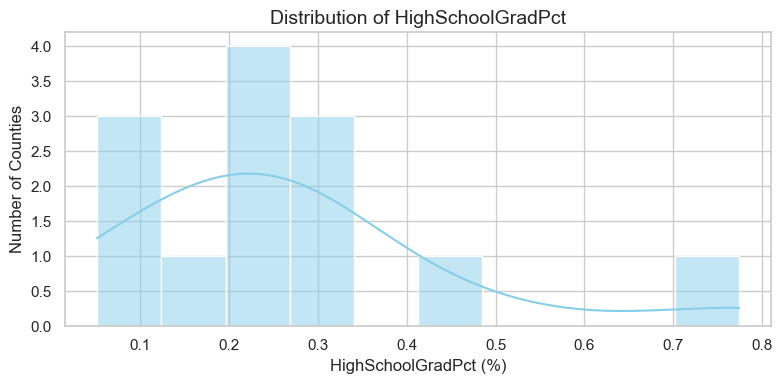

2025-07-10 10:51:38,756 [INFO] 📊 Saved: section4_2_1_distribution_povertyrate.png


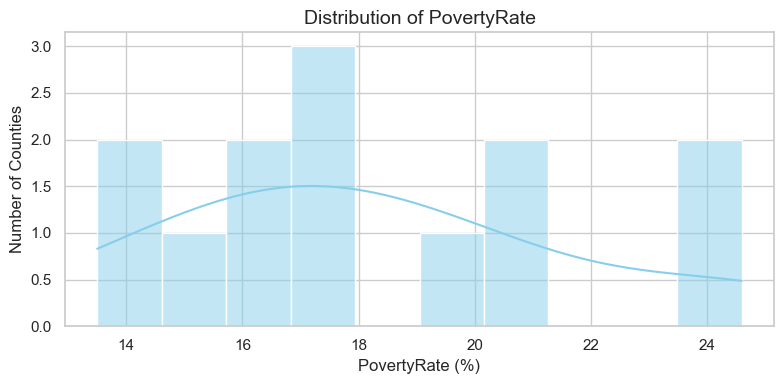

2025-07-10 10:51:38,987 [INFO] 📊 Saved: section4_2_1_distribution_unemploymentrate.png


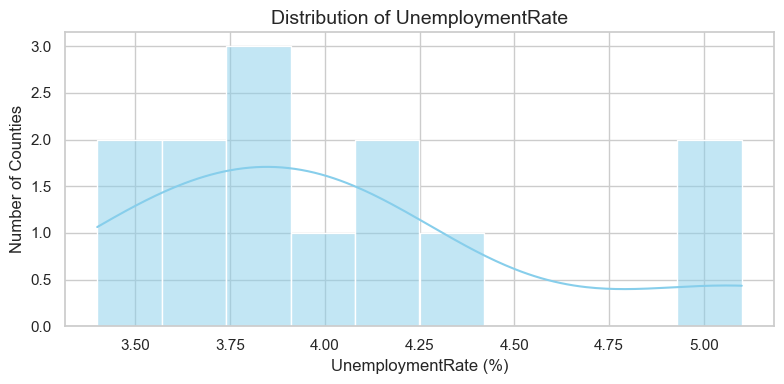

In [86]:
# Section 4.2: Distribution Plots (Histogram + KDE)

# Variables to plot
variables = [
    'BachelorsDegreePct',
    'HighSchoolGradPct',
    'PovertyRate',
    'UnemploymentRate'
]

for var in variables:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_nca_final[var], kde=True, bins=10, color='skyblue')

    plt.title(f"Distribution of {var}", fontsize=14)
    plt.xlabel(f"{var} (%)", fontsize=12)
    plt.ylabel("Number of Counties", fontsize=12)
    plt.tight_layout()

    # Save
    filename = f"section4_2_1_distribution_{var.lower()}.png"
    plt.savefig(image_dir / filename, dpi=300, bbox_inches='tight')
    logging.info(f"📊 Saved: {filename}")
    plt.show()


## Section 4.3 Dot Plots

2025-07-10 10:51:39,366 [INFO] [Section 4.3] Saved: section4_3_dotplot_bachelorsdegreepct.png


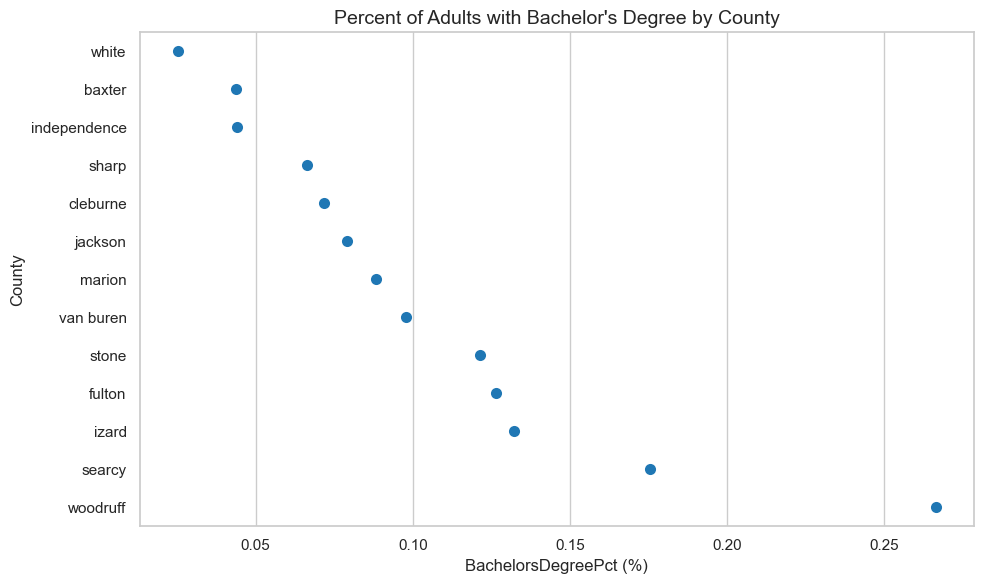

2025-07-10 10:51:39,673 [INFO] [Section 4.3] Saved: section4_3_dotplot_highschoolgradpct.png


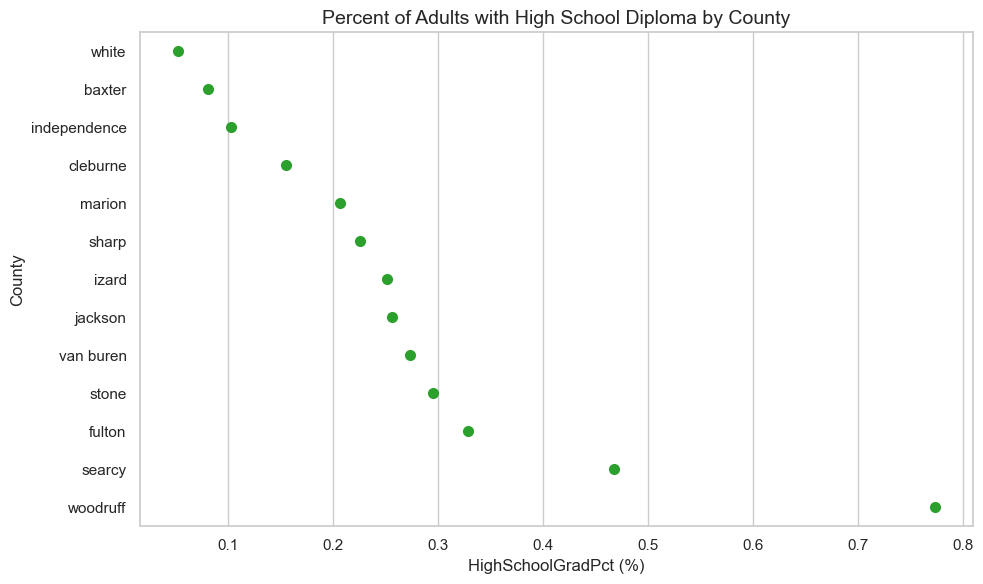

2025-07-10 10:51:40,018 [INFO] [Section 4.3] Saved: section4_3_dotplot_povertyrate.png


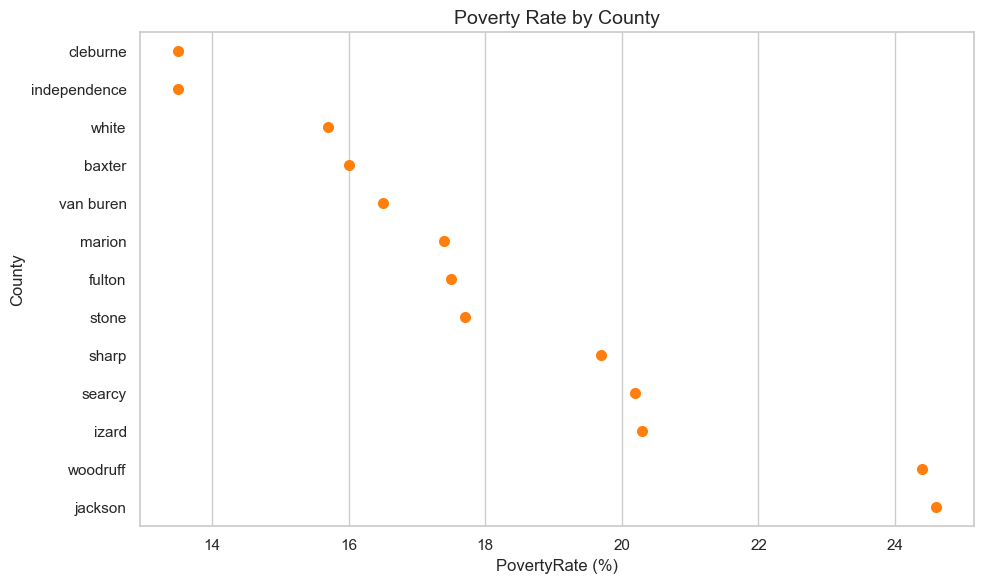

2025-07-10 10:51:40,358 [INFO] [Section 4.3] Saved: section4_3_dotplot_unemploymentrate.png


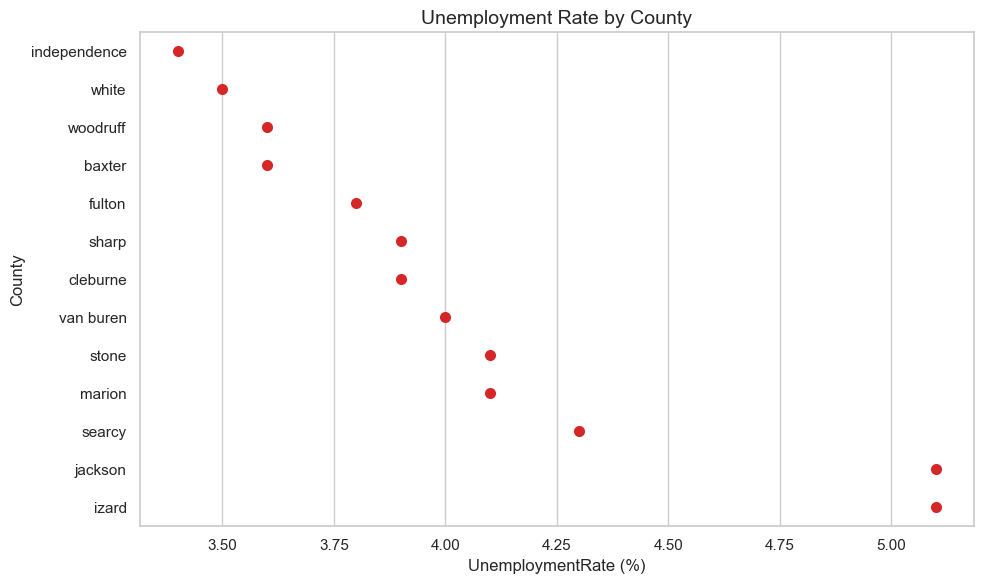

In [87]:
# Section 4.3: Dot Plots by County for Key Indicators

dot_vars = {
    "BachelorsDegreePct": "Percent of Adults with Bachelor's Degree by County",
    "HighSchoolGradPct": "Percent of Adults with High School Diploma by County",
    "PovertyRate": "Poverty Rate by County",
    "UnemploymentRate": "Unemployment Rate by County"
}

for var, title in dot_vars.items():
    df_plot = df_nca_final.reset_index().sort_values(var)

    plt.figure(figsize=(10, 6))
    sns.stripplot(y='county', x=var, data=df_plot,
                  size=8, color=variable_colors[var], jitter=False)
    
    plt.title(title, fontsize=14)
    plt.xlabel(f"{var} (%)")
    plt.ylabel("County")
    plt.tight_layout()

    filename = f"section4_3_dotplot_{var.lower()}.png"
    plt.savefig(image_dir / filename, dpi=300, bbox_inches='tight')
    logging.info(f"[Section 4.3] Saved: {filename}")
    plt.show()

## Section 4.4 PairPlot of Variables

2025-07-10 10:51:41,496 [INFO] [Section 4.6] Saved: section4_6_pairplot_indicators.png


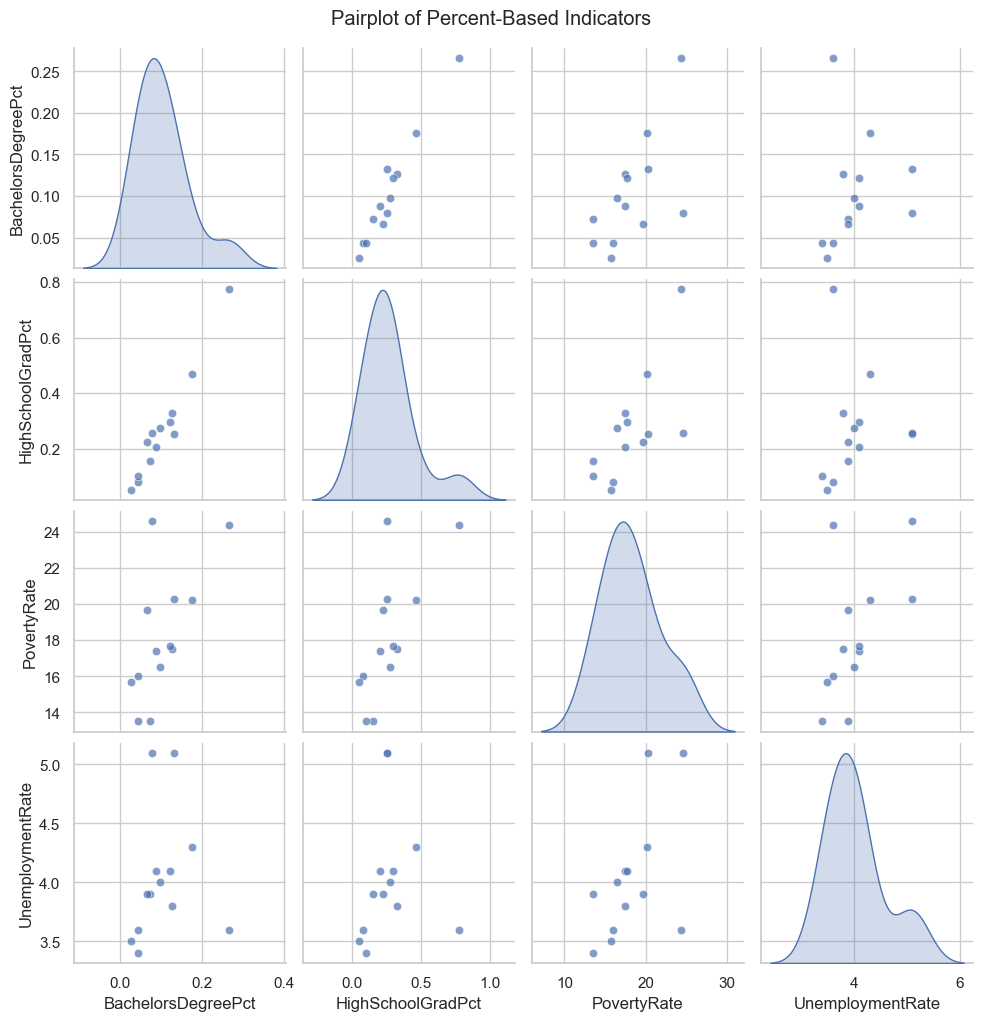

In [88]:
# Section 4.6: Pairplot of All Percent-Based Variables
sns.pairplot(df_nca_final.reset_index(), vars=[
    'BachelorsDegreePct', 'HighSchoolGradPct', 'PovertyRate', 'UnemploymentRate'
], kind='scatter', diag_kind='kde', plot_kws={'alpha': 0.7})

plt.suptitle("Pairplot of Percent-Based Indicators", y=1.02)
filename = "section4_6_pairplot_indicators.png"
plt.savefig(image_dir / filename, dpi=300, bbox_inches='tight')
logging.info(f"[Section 4.6] Saved: {filename}")
plt.show()



## Section 4.5 Correlation HeatMap

2025-07-10 10:51:42,042 [INFO] [Section 4.5] Saved: section4_5_correlation_heatmap.png


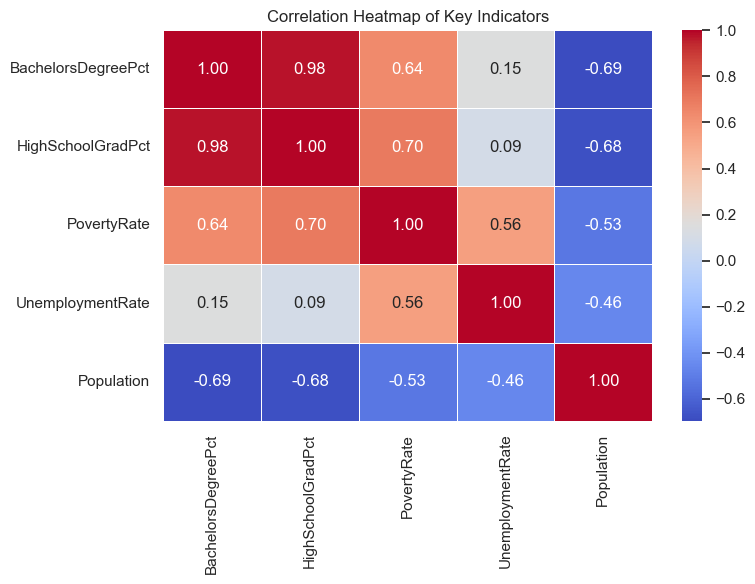

In [89]:
# Section 4.5: Correlation Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(df_nca_final.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Key Indicators")
plt.tight_layout()

# Save
filename = "section4_5_correlation_heatmap.png"
plt.savefig(image_dir / filename, dpi=300)
logging.info(f"[Section 4.5] Saved: {filename}")
plt.show()


## Section 4.6: Boxplots of Key Indicators

2025-07-10 10:51:42,201 [INFO] [Section 4.7] Saved boxplot with labels: section4_7_boxplot_bachelorsdegreepct_labeled.png


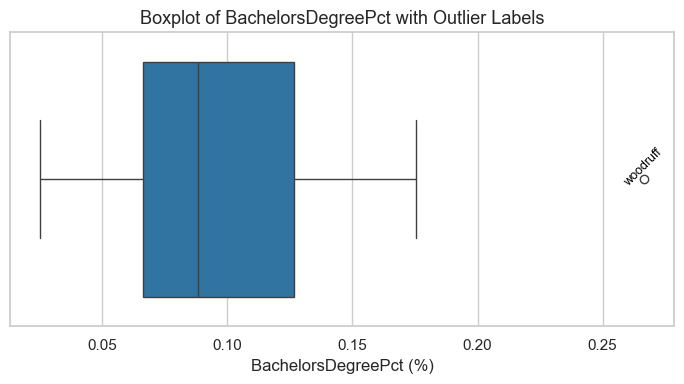

2025-07-10 10:51:42,326 [INFO] [Section 4.7] Saved boxplot with labels: section4_7_boxplot_highschoolgradpct_labeled.png


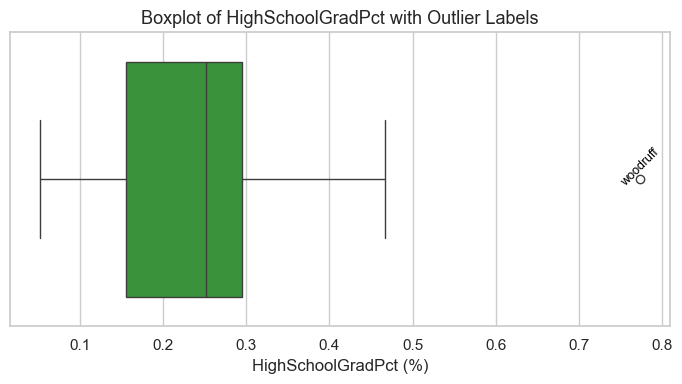

2025-07-10 10:51:42,453 [INFO] [Section 4.7] Saved boxplot with labels: section4_7_boxplot_povertyrate_labeled.png


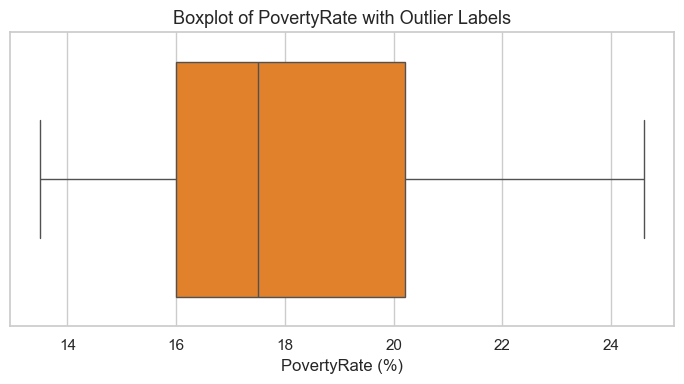

2025-07-10 10:51:42,591 [INFO] [Section 4.7] Saved boxplot with labels: section4_7_boxplot_unemploymentrate_labeled.png


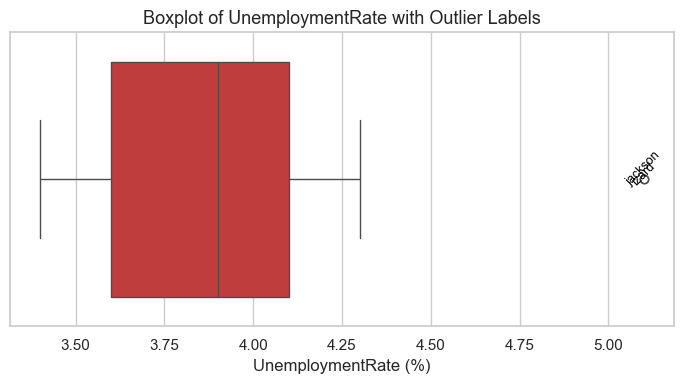

In [90]:
# Section 4.6: Boxplots with Outlier Labels for All Variables

# Boxplots with Outlier Labels and Global Color Mapping

percent_vars = ['BachelorsDegreePct', 'HighSchoolGradPct', 'PovertyRate', 'UnemploymentRate']

def label_outliers_with_color(df, var):
    # Calculate IQR bounds
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

    # Plot with color from global palette
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=var, data=df, color=variable_colors.get(var, 'gray'))

    # Annotate each outlier with the county name
    for i, row in outliers.iterrows():
        plt.text(row[var], 0.02, row.name, fontsize=9, rotation=45, ha='center', color='black')

    # Labels and styling
    plt.title(f"Boxplot of {var} with Outlier Labels", fontsize=13)
    plt.xlabel(f"{var} (%)")
    plt.yticks([])
    plt.tight_layout()

    # Save image
    filename = f"section4_7_boxplot_{var.lower()}_labeled.png"
    plt.savefig(image_dir / filename, dpi=300)
    logging.info(f"[Section 4.7] Saved boxplot with labels: {filename}")
    plt.show()

# Run the loop for each variable
for var in percent_vars:
    label_outliers_with_color(df_nca_final, var)




## Section 5: 